<a href="https://colab.research.google.com/github/rose72001/Firstrepo/blob/main/Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

# 1. Connect Colab to your Drive
drive.mount('/content/drive')

# 2. Define the exact path
target_path = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Raw/images'

# 3. Build the folders automatically
os.makedirs(target_path, exist_ok=True)

print(f"Success! Your folder path is ready at: {target_path}")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import drive
import os

# 1. Force Google Colab to reconnect to your Drive
drive.mount('/content/drive', force_remount=True)

# 2. Define the exact, absolute paths (No guessing allowed)
zip_file = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Raw/flow-img.zip'
output_folder = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/'

# 3. Build the output folder
os.makedirs(output_folder, exist_ok=True)

# 4. Execute the unzip using absolute paths
print("Connection restored. Unzipping the dataset...")
!unzip -q "{zip_file}" -d "{output_folder}"

# 5. Prove it worked
print("\nUnzipping Complete! The YOLO folders are ready:")
!ls "{output_folder}"

Mounted at /content/drive
Connection restored. Unzipping the dataset...
replace /content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A

Unzipping Complete! The YOLO folders are ready:
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
import torch
import torchvision
from PIL import Image
import numpy as np
from tqdm import tqdm
import sys
import os

# 1. Ensure Zero-DCE is downloaded
if not os.path.exists('/content/Zero-DCE'):
    os.system('git clone https://github.com/Li-Chongyi/Zero-DCE.git /content/Zero-DCE')

sys.path.append('/content/Zero-DCE/Zero-DCE_code')
import model

def run_bulletproof_enhancement():
    print("Loading Zero-DCE Model into GPU...")
    DCE_net = model.enhance_net_nopool().cuda()
    # Load pre-trained weights
    DCE_net.load_state_dict(torch.load('/content/Zero-DCE/Zero-DCE_code/snapshots/Epoch99.pth'))
    DCE_net.eval()

    # Point to your newly unzipped dataset
    base_dir = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/'

    # The Radar: Find ALL image formats deeply nested in train/test/valid
    image_list = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith(valid_extensions):
                image_list.append(os.path.join(root, file))

    print(f"Radar found {len(image_list)} images. Starting AI enhancement...")

    for image_path in tqdm(image_list):
        try:
            # Load and normalize
            data_lowlight = Image.open(image_path).convert('RGB')
            data_lowlight = (np.asarray(data_lowlight)/255.0)
            data_lowlight = torch.from_numpy(data_lowlight).float()
            data_lowlight = data_lowlight.permute(2,0,1).cuda().unsqueeze(0)

            # Enhance the image using the neural network
            with torch.no_grad():
                _, enhanced_image, _ = DCE_net(data_lowlight)

            # Overwrite the original image with the brightened version
            torchvision.utils.save_image(enhanced_image, image_path)

        except Exception as e:
            print(f"\nSkipped {os.path.basename(image_path)} due to error: {e}")

    print("\nPhase 1 Complete! All images enhanced and labels preserved.")

run_bulletproof_enhancement()

Loading Zero-DCE Model into GPU...
Radar found 2000 images. Starting AI enhancement...


100%|██████████| 2000/2000 [03:32<00:00,  9.42it/s]


Phase 1 Complete! All images enhanced and labels preserved.


In [ ]:
import yaml
import os

print("Wiring configuration files...")

# 1. Update the Roboflow data.yaml with absolute Drive paths
yaml_path = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Force the paths to look at your Google Drive
data['path'] = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced'
data['train'] = 'train/images'
data['val'] = 'valid/images'
data['test'] = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
print("✅ Dataset paths updated successfully!")

# 2. Build the aggressive hyperparameter file
hyp_config = {
    'mosaic': 1.0,      # 100% chance to stitch 4 images together (forces AI to look harder)
    'cutmix': 1.0,      # 100% chance to paste garbage patches over other objects
    'degrees': 10.0,    # Slight rotation to simulate water movement
    'fliplr': 0.5       # 50% chance to flip images horizontally
}

with open('/content/custom_hyp.yaml', 'w') as f:
    yaml.dump(hyp_config, f, sort_keys=False)
print("✅ Math configurations injected!")

Wiring configuration files...
✅ Dataset paths updated successfully!
✅ Math configurations injected!


In [ ]:
# Install the framework silently
!pip install ultralytics -q
from ultralytics import RTDETR

print("Initializing RT-DETR Transformer...")

# 1. Load the pre-trained weights to prevent overfitting
model = RTDETR('rtdetr-l.pt')

# 2. Start the training loop
# batch=16 prevents Colab from running out of memory
# project/name saves the weights securely to your Drive so nothing is lost!
results = model.train(
    data='/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/data.yaml',
    cfg='/content/custom_hyp.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='/content/drive/MyDrive/USV_Thesis_Project/rtdetr_training',
    name='first_run_results'
)

print("Training Complete! Check your Google Drive for the results folder.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Initializing RT-DETR Transformer...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=/content/custom_hyp.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=1.0, data=/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2en

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      12.3G     0.9521      1.019      0.195         42        640: 100% ━━━━━━━━━━━━ 88/88 1.6s/it 2:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.0s/it 13.3s
                   all        400       1046      0.739      0.727      0.749      0.326

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      12.5G     0.7958      0.497     0.1198         30        640: 100% ━━━━━━━━━━━━ 88/88 1.4s/it 2:01
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.4s
                   all        400       1046      0.614      0.514      0.503      0.203

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      48/50      12.6G     0.4753     0.4083    0.05596         27        640: 100% ━━━━━━━━━━━━ 88/88 1.2s/it 1:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.1s
                   all        400       1046      0.873      0.835      0.861      0.427

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      12.6G     0.4688     0.4094     0.0516         22        640: 100% ━━━━━━━━━━━━ 88/88 1.2s/it 1:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.3s
                   all        400       1046      0.873       0.84      0.869      0.433

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      12.8G     0.4803     0.4101    0.05421         13        640: 100% ━━━━━━━━━━━━ 88/88 1.3s/it 1:50
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.0s
                   all        400       1046      0.838      0.866      0.863      0.434

50 epochs completed in 1.744 hours.
Optimizer stripped from /content/drive/MyDrive/USV_Thesis_Project/rtdetr_training/first_run_results/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/USV_Thesis_Project/rtdetr_training/first_run_results/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/USV_Thesis_Project/rtdetr_training/first_run_results/weights/best.pt...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13

Loading your custom-trained AI brain...
Testing on image: 000167_jpg.rf.68373cfff17c995fd4bec4f139abaffc.jpg

image 1/1 /content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/test/images/000167_jpg.rf.68373cfff17c995fd4bec4f139abaffc.jpg: 640x640 2 bottles, 70.6ms
Speed: 2.9ms preprocess, 70.6ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/USV_Thesis_Project/rtdetr_inference/visual_test

--- DETECTION RESULT ---


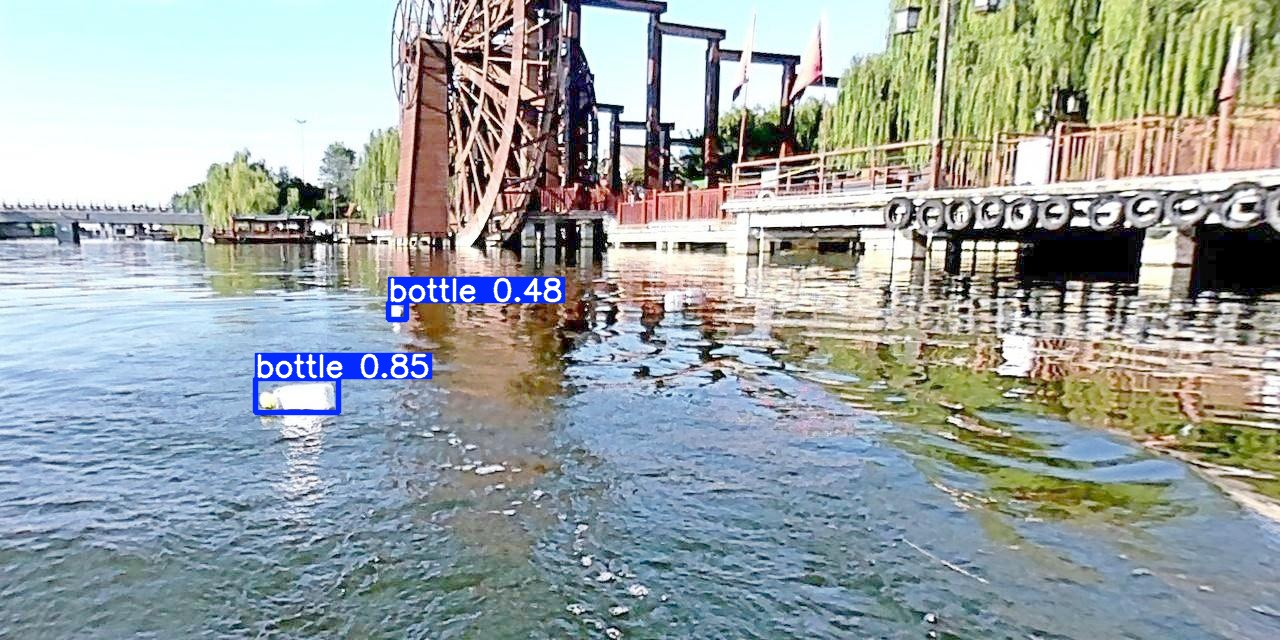

In [ ]:
from ultralytics import RTDETR
import glob
import random
import os
from IPython.display import Image, display

print("Loading your custom-trained AI brain...")
# 1. Point to the 'best.pt' file your training just generated
model_path = '/content/drive/MyDrive/USV_Thesis_Project/rtdetr_training/first_run_results/weights/best.pt'
model = RTDETR(model_path)

# 2. Find all the testing images it has never seen before
test_dir = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/test/images/'
all_test_images = glob.glob(test_dir + '*.*')

# Pick a random image from the test set
test_img = random.choice(all_test_images)
print(f"Testing on image: {os.path.basename(test_img)}")

# 3. Run Inference! (conf=0.4 means it only shows boxes it is at least 40% confident about)
results = model.predict(
    source=test_img,
    save=True,
    project='/content/drive/MyDrive/USV_Thesis_Project/rtdetr_inference',
    name='visual_test',
    conf=0.4
)

# 4. Display the result right here in Colab
result_path = os.path.join(results[0].save_dir, os.path.basename(test_img))
print("\n--- DETECTION RESULT ---")
display(Image(filename=result_path))

In [ ]:
# 1. Reconnect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Re-install the framework silently
!pip install ultralytics -q

import time
import glob
from ultralytics import RTDETR

# 3. Load your custom-trained model
model_path = '/content/drive/MyDrive/USV_Thesis_Project/rtdetr_training/first_run_results/weights/best.pt'
model = RTDETR(model_path)

# 4. Point it to the test images
test_dir = '/content/drive/MyDrive/USV_Thesis_Project/datasets/Flow_Enhanced/test/images/'
test_images = glob.glob(test_dir + '*.*')

print(f"Starting FPS benchmark on {len(test_images)} unseen images...")

# 5. WARM-UP PHASE
print("Warming up the T4 GPU engine...")
for img in test_images[:10]:
    model.predict(img, verbose=False)

# 6. THE REAL TEST
print("Measuring maximum inference speed...")
start_time = time.time()

# Process every image in the test set
for img in test_images:
    model.predict(img, verbose=False)

end_time = time.time()

# 7. CALCULATE AND PRINT RESULTS
total_time = end_time - start_time
fps = len(test_images) / total_time

print("\n" + "="*30)
print("🚀 SPEED TEST RESULTS 🚀")
print("="*30)
print(f"Total Images Processed: {len(test_images)}")
print(f"Total Time Taken:     {total_time:.2f} seconds")
print(f"Average Speed:        {fps:.2f} FPS")
print("="*30)

Mounted at /content/drive
Starting FPS benchmark on 200 unseen images...
Warming up the T4 GPU engine...
Measuring maximum inference speed...

🚀 SPEED TEST RESULTS 🚀
Total Images Processed: 200
Total Time Taken:     19.85 seconds
Average Speed:        10.07 FPS


In [1]:
!git config --global user.email "guptarose72001@gmail.com"
!git config --global user.name "rose72001"

In [2]:
# 1. Move into your project directory
%cd /content/drive/MyDrive/USV_Thesis_Project

# 2. Initialize the local folder as a Git repo
!git init

# 3. Add all files (or specific ones like your .ipynb)
!git add Thesis.ipynb custom_hyp.yaml

# 4. Commit the changes
!git commit -m "Initial commit: Added Zero-DCE enhancement and RT-DETR training script"

# 5. Rename the branch to main
!git branch -M main

# 6. Add the remote origin (Using your Token for authentication)
!git remote add origin https://Thesis@github.com/rose72001/GarbageDetection.git

# 7. Push to GitHub
!git push -u origin main

[Errno 2] No such file or directory: '/content/drive/MyDrive/USV_Thesis_Project'
/content
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
fatal: pathspec 'Thesis.ipynb' did not match any files
On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/ros